In [80]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from process_and_save_recording import load_recording, combine_accel_gyro, add_annotations_to_combined, add_predictions_to_combined

# Load recording

In [ ]:
# session_1776422910441
path = "session_1776456312980"
accel, gyro, classification, annotations, info = load_recording(path)
accel.shape, gyro.shape, classification.shape, annotations.keys(), len(annotations["events"]), info

((30528, 4),
 (30528, 4),
 (576, 8),
 dict_keys(['phoneStartTimestamp', 'phoneEndTimestamp', 'events']),
 10,
 ['start_time=1776422911943',
  'phone_timestamp=1776422910441',
  'end_time=1776423765740'])

In [82]:
accel

,timestamp,x,y,z
0,75770674366887,-9.794679,-0.040701,0.770933
1,75770694447156,-9.751583,0.002394,0.770933
2,75770714547348,-9.753978,-0.040701,0.706290
3,75770734657810,-9.780314,0.004788,0.746991
4,75770754772464,-9.742006,-0.021548,0.751779
...,...,...,...,...
30523,76624378420784,-9.737218,-0.040701,0.715866
30524,76624398519784,-9.730036,-0.016759,0.715866
30525,76624418607245,-9.775525,0.000000,0.742202
30526,76624438701553,-9.749189,-0.059855,0.754174


In [83]:
gyro

,timestamp,x,y,z
0,75770674369310,0.000000,-0.003665,-0.001222
1,75770694449387,0.000000,-0.002443,-0.002443
2,75770714549771,0.001222,-0.001222,-0.001222
3,75770734660002,0.001222,-0.003665,-0.002443
4,75770754774887,-0.001222,-0.003665,-0.001222
...,...,...,...,...
30523,76624378423246,-0.002443,-0.003665,0.000000
30524,76624398521976,0.000000,-0.002443,-0.001222
30525,76624418609669,-0.001222,-0.001222,-0.001222
30526,76624438703745,-0.001222,-0.002443,0.000000


In [84]:
classification

,timestamp,prediction_float,prediction_binary,start_accel_ts,end_accel_ts,start_gyro_ts,end_gyro_ts,window_data
0,1776422911988,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
1,1776422913042,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
2,1776422914854,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
3,1776422916394,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
4,1776422917458,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
...,...,...,...,...,...,...,...,...
571,1776423755443,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
572,1776423757335,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
573,1776423758941,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
574,1776423761686,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....


In [85]:
annotations

{'phoneStartTimestamp': 1776670910347,
 'phoneEndTimestamp': 1776671876450,
 'events': [{'name': 'Crunches',
   'startTime': 1776671802566,
   'endTime': 1776671833190},
  {'name': 'Dumbbell Rows',
   'startTime': 1776671672141,
   'endTime': 1776671707282},
  {'name': 'Push-ups', 'startTime': 1776671581882, 'endTime': 1776671602628},
  {'name': 'Dumbbell Lateral Raises',
   'startTime': 1776671419298,
   'endTime': 1776671459057},
  {'name': 'Overhead Extensions',
   'startTime': 1776671325537,
   'endTime': 1776671352028},
  {'name': 'Dumbbell Bicep Curls',
   'startTime': 1776671278835,
   'endTime': 1776671307844},
  {'name': 'Bulgarian Split Squat',
   'startTime': 1776671154887,
   'endTime': 1776671179052},
  {'name': 'Bulgarian Split Squat',
   'startTime': 1776671110986,
   'endTime': 1776671137936},
  {'name': 'Stiff-Leg Deadlifts',
   'startTime': 1776671019878,
   'endTime': 1776671059820},
  {'name': 'Goblet Squats',
   'startTime': 1776670943875,
   'endTime': 17766709675

In [86]:
info

['start_time=1776422911943',
 'phone_timestamp=1776422910441',
 'end_time=1776423765740']

# Sanity check recording

## Start and end timestamps

In [87]:
def print_recording_stats(accel, gyro, classification, annotations, info):
    phone_start_timestamp = annotations["phoneStartTimestamp"]
    phone_end_timestamp = annotations["phoneEndTimestamp"]
    watch_start_timestamp = int(info[0].split('=')[1])
    watch_end_timestamp = int(info[2].split('=')[1])
    print(f"Phone start timestamp:\t {phone_start_timestamp}\t ({pd.to_datetime(phone_start_timestamp, unit='ms')})")
    print(f"Phone end timestamp:\t {phone_end_timestamp}\t ({pd.to_datetime(phone_end_timestamp, unit='ms')})")
    print("Duration of phone recording:", pd.to_timedelta(phone_end_timestamp - phone_start_timestamp, unit='ms'))
    print(f"Watch start timestamp:\t {watch_start_timestamp}\t ({pd.to_datetime(watch_start_timestamp, unit='ms')})")
    print(f"Watch end timestamp:\t {watch_end_timestamp}\t ({pd.to_datetime(watch_end_timestamp, unit='ms')})")
    print("Duration of watch recording:", pd.to_timedelta(watch_end_timestamp - watch_start_timestamp, unit='ms'))
    print("Duration difference between phone and watch recordings (ms):", (phone_end_timestamp - phone_start_timestamp) - (watch_end_timestamp - watch_start_timestamp))
    print("Difference between phone and watch start timestamps (ms):", phone_start_timestamp - watch_start_timestamp)
    print("Difference between phone and watch end timestamps (ms):", phone_end_timestamp - watch_end_timestamp)

In [88]:
print_recording_stats(accel, gyro, classification, annotations, info)

Phone start timestamp:	 1776670910347	 (2026-04-20 07:41:50.347000)
Phone end timestamp:	 1776671876450	 (2026-04-20 07:57:56.450000)
Duration of phone recording: 0 days 00:16:06.103000
Watch start timestamp:	 1776422911943	 (2026-04-17 10:48:31.943000)
Watch end timestamp:	 1776423765740	 (2026-04-17 11:02:45.740000)
Duration of watch recording: 0 days 00:14:13.797000
Duration difference between phone and watch recordings (ms): 112306
Difference between phone and watch start timestamps (ms): 247998404
Difference between phone and watch end timestamps (ms): 248110710


In [89]:
def print_recording_imu_stats(accel, gyro):
    # accel, gyro timestamps are in nanoseconds
    print(f"First accel timestamp:\t {accel['timestamp'][0]}\t ({pd.to_datetime(accel['timestamp'][0], unit='ns')})")
    print(f"First gyro timestamp:\t {gyro['timestamp'][0]}\t ({pd.to_datetime(gyro['timestamp'][0], unit='ns')})")
    print("Duration of accel recording:", pd.to_timedelta(accel['timestamp'].iloc[-1] - accel['timestamp'][0], unit='ns'))
    print(f"Last accel timestamp:\t {accel['timestamp'].iloc[-1]}\t ({pd.to_datetime(accel['timestamp'].iloc[-1], unit='ns')})")
    print(f"Last gyro timestamp:\t {gyro['timestamp'].iloc[-1]}\t ({pd.to_datetime(gyro['timestamp'].iloc[-1], unit='ns')})")
    print("Duration of gyro recording:", pd.to_timedelta(gyro['timestamp'].iloc[-1] - gyro['timestamp'][0], unit='ns'))
    print("Duration difference between accel and gyro recordings (ns):", (accel['timestamp'].iloc[-1] - accel['timestamp'][0]) - (gyro['timestamp'].iloc[-1] - gyro['timestamp'][0]))
    print("Difference between accel and gyro start timestamps (ns):", accel['timestamp'][0] - gyro['timestamp'][0])
    print("Difference between accel and gyro end timestamps (ns):", accel['timestamp'].iloc[-1] - gyro['timestamp'].iloc[-1])

In [90]:
print_recording_imu_stats(accel, gyro)

First accel timestamp:	 75770674366887	 (1970-01-01 21:02:50.674366887)
First gyro timestamp:	 75770674369310	 (1970-01-01 21:02:50.674369310)
Duration of accel recording: 0 days 00:14:13.784435935
Last accel timestamp:	 76624458802822	 (1970-01-01 21:17:04.458802822)
Last gyro timestamp:	 76624458805245	 (1970-01-01 21:17:04.458805245)
Duration of gyro recording: 0 days 00:14:13.784435935
Duration difference between accel and gyro recordings (ns): 0
Difference between accel and gyro start timestamps (ns): -2423
Difference between accel and gyro end timestamps (ns): -2423


## Sorted? Duplicates?

In [91]:
# is accel and gyro sorted?
print("Is accel sorted by timestamp?", accel['timestamp'].is_monotonic_increasing)
print("Is gyro sorted by timestamp?", gyro['timestamp'].is_monotonic_increasing)

Is accel sorted by timestamp? True
Is gyro sorted by timestamp? True


In [92]:
# detect duplicates
accel_duplicates = accel[accel.duplicated(subset='timestamp', keep=False)]
gyro_duplicates = gyro[gyro.duplicated(subset='timestamp', keep=False)]
print(f"Number of duplicate timestamps in accel: {len(accel_duplicates)}")
print(f"Number of duplicate timestamps in gyro: {len(gyro_duplicates)}")

Number of duplicate timestamps in accel: 0
Number of duplicate timestamps in gyro: 0


## Differences in rows and sequential rows

In [93]:
# Compare timestamps row by row
def compare_timestamps(accel, gyro, threshold_ms=1):
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff = accel_ts - gyro_ts
        if abs(diff) > threshold_ms * 1_000_000:  # Convert ms to nanoseconds
            print(f"Row {idx}: accel={accel_ts}, gyro={gyro_ts}, diff={(diff) / 1_000_000:.2f}ms")

In [94]:
# Are accel and gyro timestamps aligned?
compare_timestamps(accel, gyro, threshold_ms=1)

In [95]:
# Sequential differences between consecutive rows
def print_sequential_differences(accel, gyro, threshold_ms=22):
    print(f"Sequential timestamp differences (>={threshold_ms}ms):")
    for idx in range(len(accel) - 1):
        accel_curr = accel.iloc[idx]['timestamp']
        accel_next = accel.iloc[idx + 1]['timestamp']
        accel_seq_diff_ms = (accel_next - accel_curr) / 1_000_000  # Convert ns to ms
    
        gyro_curr = gyro.iloc[idx]['timestamp']
        gyro_next = gyro.iloc[idx + 1]['timestamp']
        gyro_seq_diff_ms = (gyro_next - gyro_curr) / 1_000_000  # Convert ns to ms
        
        if accel_seq_diff_ms > threshold_ms or gyro_seq_diff_ms > threshold_ms:
            print(f"Row {idx}->{idx+1}: accel_diff={accel_seq_diff_ms:.2f}ms, gyro_diff={gyro_seq_diff_ms:.2f}ms")
            # print out few rows timestamps and time diff around the gap for context
            accels = accel.iloc[max(0, idx-5):min(len(accel), idx+5)][['timestamp']]
            gyros = gyro.iloc[max(0, idx-5):min(len(gyro), idx+5)][['timestamp']]
            print("Accel timestamps around gap:")
            for i, row in accels.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - accel_curr) / 1_000_000:.2f}ms from current)")
            print("Gyro timestamps around gap:")
            for i, row in gyros.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - gyro_curr) / 1_000_000:.2f}ms from current)")

In [96]:
len(accel)

30528

In [97]:
print_sequential_differences(accel, gyro, threshold_ms=25)

Sequential timestamp differences (>=25ms):
Row 107->108: accel_diff=702.13ms, gyro_diff=702.13ms
Accel timestamps around gap:
Row 102: 75772721861994 (-100.38ms from current)
Row 103: 75772741946917 (-80.30ms from current)
Row 104: 75772762021340 (-60.22ms from current)
Row 105: 75772782094840 (-40.15ms from current)
Row 106: 75772802167994 (-20.08ms from current)
Row 107: 75772822244879 (0.00ms from current)
Row 108: 75773524374491 (702.13ms from current)
Row 109: 75773544463414 (722.22ms from current)
Row 110: 75773564533376 (742.29ms from current)
Row 111: 75773584612414 (762.37ms from current)
Gyro timestamps around gap:
Row 102: 75772721866879 (-100.38ms from current)
Row 103: 75772741951302 (-80.30ms from current)
Row 104: 75772762026187 (-60.22ms from current)
Row 105: 75772782099225 (-40.15ms from current)
Row 106: 75772802172879 (-20.08ms from current)
Row 107: 75772822249263 (0.00ms from current)
Row 108: 75773524376953 (702.13ms from current)
Row 109: 75773544465607 (722.22m

## Difference statistics

In [111]:
# Calculate statistics for differences
def calculate_accel_gyro_differences(accel, gyro):
    accel_gyro_diffs_ms = []
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff_ms = abs(accel_ts - gyro_ts) / 1_000_000
        accel_gyro_diffs_ms.append(diff_ms)
    return accel_gyro_diffs_ms

def calculate_sequential_differences(accel, gyro):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx in range(len(accel) - 1):
        accel_seq_diff = (accel.iloc[idx + 1]['timestamp'] - accel.iloc[idx]['timestamp']) / 1_000_000
        gyro_seq_diff = (gyro.iloc[idx + 1]['timestamp'] - gyro.iloc[idx]['timestamp']) / 1_000_000
        accel_seq_diffs_ms.append(accel_seq_diff)
        gyro_seq_diffs_ms.append(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

def print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms):
    print("=" * 60)
    print("ACCEL-GYRO SYNC DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_gyro_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gyro_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_gyro_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_gyro_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_gyro_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gyro_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gyro_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("ACCEL SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_seq_diffs_ms, 75):.4f}ms")
    print(f" (95%): {np.percentile(accel_seq_diffs_ms, 99):.4f}ms")

    print("\n" + "=" * 60)
    print("GYRO SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(gyro_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(gyro_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(gyro_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(gyro_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_seq_diffs_ms, 75):.4f}ms")

def calculate_and_print_difference_stats(accel, gyro):
# Accel-Gyro timestamp differences (sync differences)
    accel_gyro_diffs_ms = calculate_accel_gyro_differences(accel, gyro)
    accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_sequential_differences(accel, gyro)
    print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

In [112]:
calculate_and_print_difference_stats(accel, gyro)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0028ms
Std Dev: 0.0010ms
Min: 0.0022ms
Max: 0.0049ms
Median: 0.0024ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0025ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 27.9682ms
Std Dev: 65.1255ms
Min: 19.8777ms
Max: 882.8036ms
Median: 20.0797ms
Q1 (25%): 20.0592ms
Q3 (75%): 20.0995ms
 (95%): 521.4424ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 27.9682ms
Std Dev: 65.1253ms
Min: 19.8774ms
Max: 882.8012ms
Median: 20.0797ms
Q1 (25%): 20.0592ms
Q3 (75%): 20.0995ms


## Classifications

In [100]:
classification

,timestamp,prediction_float,prediction_binary,start_accel_ts,end_accel_ts,start_gyro_ts,end_gyro_ts,window_data
0,1776422911988,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
1,1776422913042,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
2,1776422914854,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
3,1776422916394,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
4,1776422917458,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
...,...,...,...,...,...,...,...,...
571,1776423755443,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
572,1776423757335,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
573,1776423758941,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....
574,1776423761686,0.000013,0,0,0,0,0,0.0|0.0|0.0|0.0|0.0|0.0;0.0|0.0|0.0|0.0|0.0|0....


In [101]:
# Are timestamps in windows sorted? duplicates?
def check_classification_windows(classification):
    all_is_sorted = True
    all_no_duplicates = True
    for idx, row in classification.iterrows():
        accel_timestamps = [int(ts) for ts in row['accel_timestamps'].split(';')]
        gyro_timestamps = [int(ts) for ts in row['gyro_timestamps'].split(';')]

        # Check if accel timestamps are sorted
        accel_is_sorted = all(earlier <= later for earlier, later in zip(accel_timestamps, accel_timestamps[1:]))
        if not accel_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: accel timestamps are not sorted")

        gyro_is_sorted = all(earlier <= later for earlier, later in zip(gyro_timestamps, gyro_timestamps[1:]))
        if not gyro_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: gyro timestamps are not sorted")
        
        # Check for duplicates in accel timestamps
        accel_duplicates = pd.Series(accel_timestamps).duplicated(keep=False)
        if accel_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: accel timestamps have duplicates")

        gyro_duplicates = pd.Series(gyro_timestamps).duplicated(keep=False)
        if gyro_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: gyro timestamps have duplicates")

    if all_is_sorted:
        print("All windows have sorted timestamps.")
    else:
        print("Some windows have unsorted timestamps.")

    if all_no_duplicates:
        print("All windows have unique timestamps.")
    else:
        print("Some windows have duplicate timestamps.")

In [102]:
check_classification_windows(classification)

KeyError: 'accel_timestamps'

In [ ]:
# Check timestamp differences between windows
def check_differences_between_windows(classification):
    gaps = []
    # check how much times is inbetween end of accel timestamps of one window and start of accel timestamps of next window, same for gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_end = int(current_row['accel_timestamps'].split(';')[-1])
        next_accel_start = int(next_row['accel_timestamps'].split(';')[0])
        accel_diff_ms = (next_accel_start - current_accel_end) / 1_000_000

        current_gyro_end = int(current_row['gyro_timestamps'].split(';')[-1])
        next_gyro_start = int(next_row['gyro_timestamps'].split(';')[0])
        gyro_diff_ms = (next_gyro_start - current_gyro_end) / 1_000_000

        gaps.append((idx, accel_diff_ms, gyro_diff_ms))

    # statistics about gaps
    accel_gaps_ms = [gap[1] for gap in gaps]
    gyro_gaps_ms = [gap[2] for gap in gaps]
    print("Accel window gaps (ms):")
    print(f"Mean: {np.mean(accel_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gaps_ms):.4f}ms")
    print(f"Min: {np.min(accel_gaps_ms):.4f}ms")
    print(f"Max: {np.max(accel_gaps_ms):.4f}ms")
    print(f"Median: {np.median(accel_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gaps_ms, 75):.4f}ms")
    print("\nGyro window gaps (ms):")
    print(f"Mean: {np.mean(gyro_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_gaps_ms):.4f}ms")
    print(f"Min: {np.min(gyro_gaps_ms):.4f}ms")
    print(f"Max: {np.max(gyro_gaps_ms):.4f}ms")
    print(f"Median: {np.median(gyro_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_gaps_ms, 75):.4f}ms")


In [ ]:
check_differences_between_windows(classification)

Accel window gaps (ms):
Mean: -975.7459ms
Std Dev: 9.3091ms
Min: -1021.3917ms
Max: -941.1341ms
Median: -980.9966ms
Q1 (25%): -981.3503ms
Q3 (75%): -961.7748ms

Gyro window gaps (ms):
Mean: -975.7459ms
Std Dev: 9.3091ms
Min: -1021.3919ms
Max: -941.1344ms
Median: -980.9966ms
Q1 (25%): -981.3503ms
Q3 (75%): -961.7749ms


In [ ]:
# check overlaps between windows
def check_overlaps_between_windows(classification):
    accel_overlaps = []
    gyro_overlaps = []

    # count how many same timestamps are in this and next window for accel and gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_timestamps = set(current_row['accel_timestamps'].split(';'))
        next_accel_timestamps = set(next_row['accel_timestamps'].split(';'))
        accel_overlap = current_accel_timestamps.intersection(next_accel_timestamps)
        accel_overlaps.append(len(accel_overlap))

        current_gyro_timestamps = set(current_row['gyro_timestamps'].split(';'))
        next_gyro_timestamps = set(next_row['gyro_timestamps'].split(';'))
        gyro_overlap = current_gyro_timestamps.intersection(next_gyro_timestamps)
        gyro_overlaps.append(len(gyro_overlap))

    # overlap statistics
    print("Accel window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(accel_overlaps):.4f}")
    print(f"Std Dev: {np.std(accel_overlaps):.4f}")
    print(f"Min: {np.min(accel_overlaps):.4f}")
    print(f"Max: {np.max(accel_overlaps):.4f}")
    print(f"Median: {np.median(accel_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(accel_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(accel_overlaps, 75):.4f}")
    print("\nGyro window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(gyro_overlaps):.4f}")
    print(f"Std Dev: {np.std(gyro_overlaps):.4f}")
    print(f"Min: {np.min(gyro_overlaps):.4f}")
    print(f"Max: {np.max(gyro_overlaps):.4f}")
    print(f"Median: {np.median(gyro_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(gyro_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(gyro_overlaps, 75):.4f}")

In [ ]:
check_overlaps_between_windows(classification)

Accel window overlaps (number of shared timestamps):
Mean: 49.7223
Std Dev: 0.4616
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 49.0000
Q3 (75%): 50.0000

Gyro window overlaps (number of shared timestamps):
Mean: 49.7223
Std Dev: 0.4616
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 49.0000
Q3 (75%): 50.0000


In [ ]:
def calculate_classifiation_accel_gyro_differences(classification):
    accel_gyro_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_gyro_diffs_ms.extend(calculate_accel_gyro_differences(accel_timestamps, gyro_timestamps))
    return accel_gyro_diffs_ms

def calculate_classification_sequential_differences(classification):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_seq_diff, gyro_seq_diff = calculate_sequential_differences(accel_timestamps, gyro_timestamps)
        accel_seq_diffs_ms.extend(accel_seq_diff)
        gyro_seq_diffs_ms.extend(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

In [ ]:
accel_gyro_diffs_ms = calculate_classifiation_accel_gyro_differences(classification)
accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_classification_sequential_differences(classification)
print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0025ms
Median: 0.0022ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0267ms
Std Dev: 0.2082ms
Min: 17.6997ms
Max: 21.8813ms
Median: 20.0229ms
Q1 (25%): 20.0146ms
Q3 (75%): 20.0353ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0267ms
Std Dev: 0.2082ms
Min: 17.6994ms
Max: 21.8815ms
Median: 20.0229ms
Q1 (25%): 20.0146ms
Q3 (75%): 20.0353ms


# Create combined dataframe

In [ ]:
combined_accel_gyro = combine_accel_gyro(accel, gyro)
combined_accel_gyro.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,323781566185600,8.437167,-3.869030,3.629610,0.062308,-0.024435,0.021991
1,323781586208600,8.449138,-3.768473,3.694253,0.000000,-0.009774,0.015882
2,323781606246946,8.494628,-3.766079,3.586514,-0.050091,0.018326,0.003665
3,323781626286253,8.408437,-3.801992,3.653552,-0.057421,0.039095,0.000000
4,323781646331330,8.362946,-3.761291,3.581726,-0.068417,0.047647,0.007330


In [ ]:
annotations["events"]

[{'name': 'Crunches', 'startTime': 1776671802566, 'endTime': 1776671833190},
 {'name': 'Dumbbell Rows',
  'startTime': 1776671672141,
  'endTime': 1776671707282},
 {'name': 'Push-ups', 'startTime': 1776671581882, 'endTime': 1776671602628},
 {'name': 'Dumbbell Lateral Raises',
  'startTime': 1776671419298,
  'endTime': 1776671459057},
 {'name': 'Overhead Extensions',
  'startTime': 1776671325537,
  'endTime': 1776671352028},
 {'name': 'Dumbbell Bicep Curls',
  'startTime': 1776671278835,
  'endTime': 1776671307844},
 {'name': 'Bulgarian Split Squat',
  'startTime': 1776671154887,
  'endTime': 1776671179052},
 {'name': 'Bulgarian Split Squat',
  'startTime': 1776671110986,
  'endTime': 1776671137936},
 {'name': 'Stiff-Leg Deadlifts',
  'startTime': 1776671019878,
  'endTime': 1776671059820},
 {'name': 'Goblet Squats',
  'startTime': 1776670943875,
  'endTime': 1776670967594}]

## Add annotations column to combined dataframe

In [ ]:
def check_event_coverage(combined_accel_gyro, events_synthetic):
# Check if all events were properly masked (handles repeated events)
    print("=" * 60)
    print("EVENT COVERAGE ANALYSIS")
    print("=" * 60)

    num_events_in_annotations = len(annotations["events"])
    print(f"\nTotal events in annotations: {num_events_in_annotations}")

    # Count occurrences of each event name
    from collections import Counter
    event_names = [e['name'] for e in events_synthetic]
    event_counts = Counter(event_names)

    print(f"Event occurrences:")
    for event_name, count in sorted(event_counts.items()):
        print(f"  {event_name}: {count}")

    # For each event occurrence, show coverage
    print("\n" + "=" * 60)
    print("COVERAGE PER EVENT OCCURRENCE")
    print("=" * 60)

    for i, event in enumerate(events_synthetic):
        event_name = event['name']
        start_synthetic = event['start_time']
        end_synthetic = event['end_time']
        
        # Count rows with this event in this time window
        rows_with_event = combined_accel_gyro[
            (combined_accel_gyro['event'] == event_name) & 
            (combined_accel_gyro['timestamp'] >= start_synthetic) &
            (combined_accel_gyro['timestamp'] <= end_synthetic)
        ]
        num_rows = len(rows_with_event)
        
        # Check if event was found in combined
        if num_rows > 0:
            actual_start = rows_with_event['timestamp'].min()
            actual_end = rows_with_event['timestamp'].max()
            coverage_pct = 100 * num_rows / (end_synthetic - start_synthetic + 20)
            print(f"\n✓ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms (duration: {end_synthetic - start_synthetic}ms)")
            print(f"  Actual:   {actual_start}ms - {actual_end}ms")
            print(f"  Rows covered: {num_rows}")
            print(f"  Coverage: {coverage_pct:.1f}%")
        else:
            print(f"\n✗ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms")
            print(f"  NO ROWS FOUND IN COMBINED!")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"✓ All {num_events_in_annotations} events were masked in combined_accel_gyro")

In [ ]:
combined_with_annotations, events_synthetic = add_annotations_to_combined(combined_accel_gyro, annotations, info)
check_event_coverage(combined_with_annotations, events_synthetic)

EVENT COVERAGE ANALYSIS

Total events in annotations: 10
Event occurrences:
  Bulgarian Split Squat: 2
  Crunches: 1
  Dumbbell Bicep Curls: 1
  Dumbbell Lateral Raises: 1
  Dumbbell Rows: 1
  Goblet Squats: 1
  Overhead Extensions: 1
  Push-ups: 1
  Stiff-Leg Deadlifts: 1

COVERAGE PER EVENT OCCURRENCE

✓ Event #1 - Goblet Squats:
  Expected: 323815094185600ms - 323838813185600ms (duration: 23719000000ms)
  Actual:   323815103429164ms - 323838812216189ms
  Rows covered: 1185
  Coverage: 0.0%

✓ Event #2 - Stiff-Leg Deadlifts:
  Expected: 323891097185600ms - 323931039185600ms (duration: 39942000000ms)
  Actual:   323891108124297ms - 323931033789568ms
  Rows covered: 1994
  Coverage: 0.0%

✓ Event #3 - Bulgarian Split Squat:
  Expected: 323982205185600ms - 324009155185600ms (duration: 26950000000ms)
  Actual:   323982224407065ms - 324009152542349ms
  Rows covered: 1346
  Coverage: 0.0%

✓ Event #4 - Bulgarian Split Squat:
  Expected: 324026106185600ms - 324050271185600ms (duration: 2416

In [ ]:
def plot_recording(data, events):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Convert time to seconds
    synthetic_s = data['timestamp']

    # Add event regions with different colors
    unique_events = [e['name'] for e in events]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_events)))

    # Plot 1: Accelerometer data
    ax1.plot(synthetic_s, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_z'], label='accel_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax1.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx], label=event['name'])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    accel_data = np.concatenate([data['accel_x'].values, 
                                data['accel_y'].values,
                                data['accel_z'].values])
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.8*accel_range, accel_max + 0.8*accel_range])

    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Gyroscope data
    ax2.plot(synthetic_s, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_z'], label='gyro_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax2.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    gyro_data = np.concatenate([data['gyro_x'].values,
                                data['gyro_y'].values,
                                data['gyro_z'].values])
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.8*gyro_range, gyro_max + 0.8*gyro_range])

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print event times for verification
    print("Event synthetic times (ms):")
    for event in events:
        print(f"{event['name']}: {event['start_time']:.0f}ms - {event['end_time']:.0f}ms")


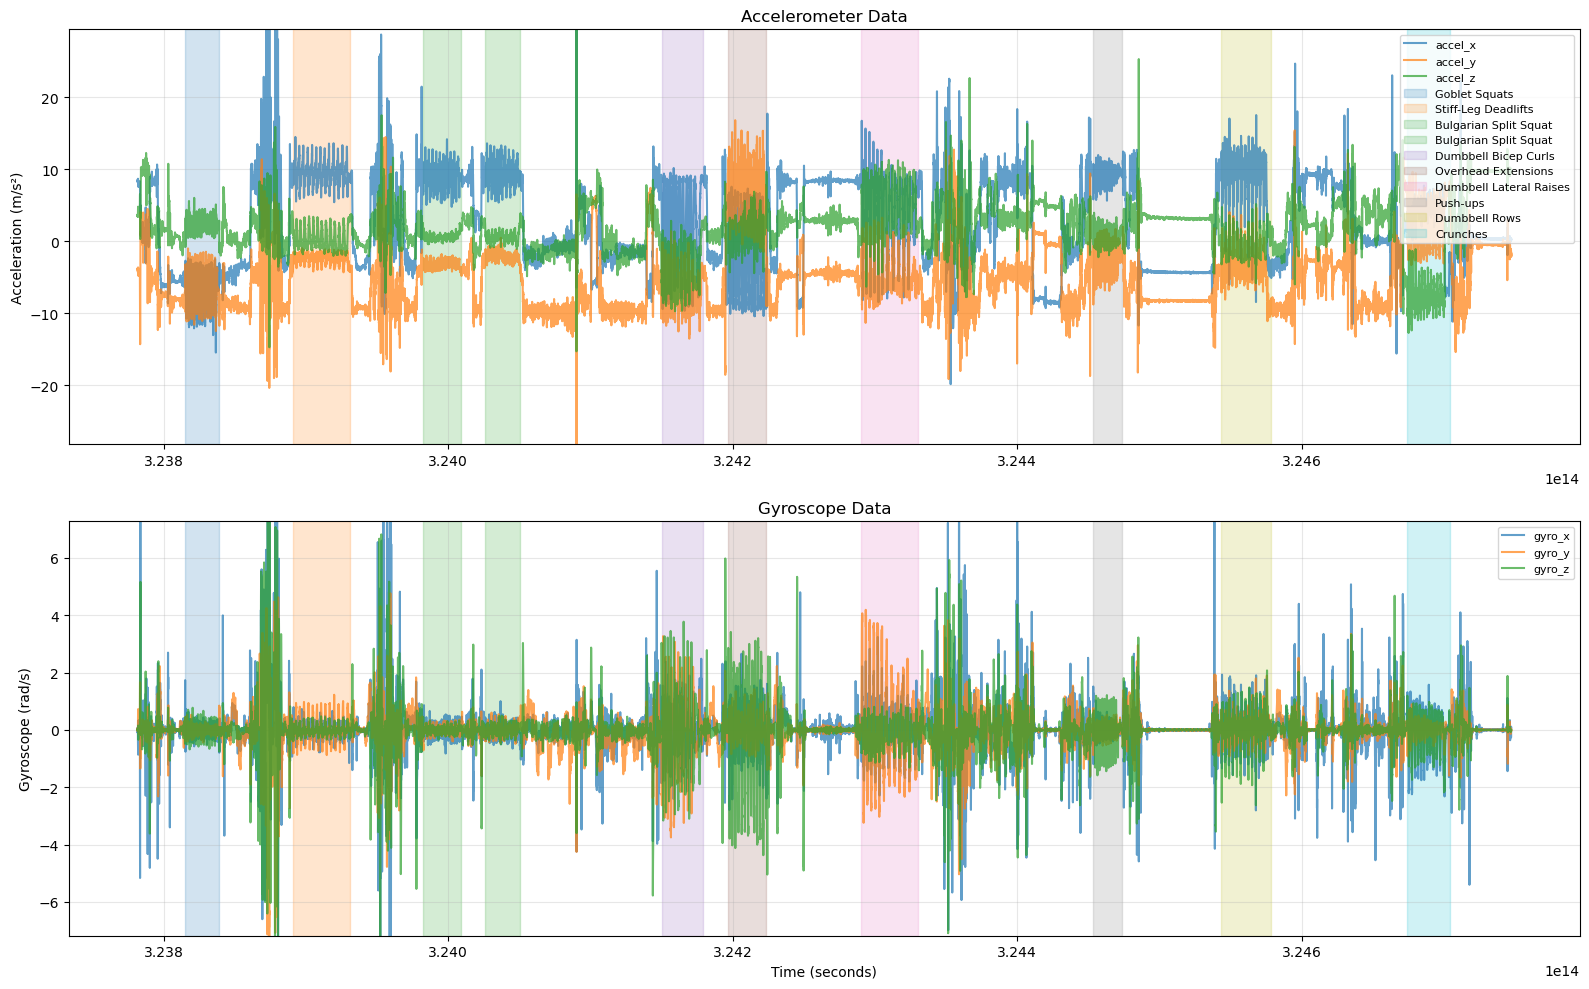

Event synthetic times (ms):
Goblet Squats: 323815094185600ms - 323838813185600ms
Stiff-Leg Deadlifts: 323891097185600ms - 323931039185600ms
Bulgarian Split Squat: 323982205185600ms - 324009155185600ms
Bulgarian Split Squat: 324026106185600ms - 324050271185600ms
Dumbbell Bicep Curls: 324150054185600ms - 324179063185600ms
Overhead Extensions: 324196756185600ms - 324223247185600ms
Dumbbell Lateral Raises: 324290517185600ms - 324330276185600ms
Push-ups: 324453101185600ms - 324473847185600ms
Dumbbell Rows: 324543360185600ms - 324578501185600ms
Crunches: 324673785185600ms - 324704409185600ms


In [ ]:
plot_recording(combined_with_annotations, events_synthetic)

In [ ]:
combined_with_annotations.iloc[38101]

timestamp    324544630796345
accel_x             7.280767
accel_y            -2.602497
accel_z            -2.200271
gyro_x              0.620639
gyro_y             -0.251676
gyro_z              0.668287
event          Dumbbell Rows
Name: 38101, dtype: object

## Add predictions column to combined dataframe

In [ ]:
# combined_with_annotations["timestamp"] matches in classification["accel_timestamps"]
def check_combined_classification_alignment(combined, classification):
    combined_timestamps = set(combined['timestamp'])
    for idx, row in classification.iterrows():
        accel_timestamps = set(int(ts) for ts in row['accel_timestamps'].split(';'))
        accel_in_combined = accel_timestamps.issubset(combined_timestamps)
        if not accel_in_combined:
            print(f"Row {idx}: Some accel timestamps not in combined")
    print("Alignment check completed.")

In [ ]:
check_combined_classification_alignment(combined_with_annotations, classification)

Row 0: Some accel timestamps not in combined
Row 1: Some accel timestamps not in combined
Alignment check completed.


In [ ]:
combined_with_predictions = add_predictions_to_combined(combined_with_annotations, classification)
combined_with_predictions.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,event,prediction_float,prediction_binary
0,323781566185600,8.437167,-3.869030,3.629610,0.062308,-0.024435,0.021991,None,0.014664,0.0
1,323781586208600,8.449138,-3.768473,3.694253,0.000000,-0.009774,0.015882,None,0.014664,0.0
2,323781606246946,8.494628,-3.766079,3.586514,-0.050091,0.018326,0.003665,None,0.014664,0.0
3,323781626286253,8.408437,-3.801992,3.653552,-0.057421,0.039095,0.000000,None,0.014664,0.0
4,323781646331330,8.362946,-3.761291,3.581726,-0.068417,0.047647,0.007330,None,0.014664,0.0
5,323781666352561,8.367735,-3.859453,3.612850,-0.089186,0.058643,0.012217,None,0.014664,0.0
6,323781686365984,8.243237,-4.005499,3.519476,-0.010996,0.041539,0.000000,None,0.014664,0.0
7,323781706387369,8.420407,-3.890578,3.538630,0.036652,0.012217,-0.009774,None,0.014664,0.0
8,323781726401599,8.370130,-3.924097,3.435679,0.008552,0.017104,-0.015882,None,0.014664,0.0
9,323781746413984,8.396465,-3.981557,3.514688,-0.014661,0.024435,-0.009774,None,0.014664,0.0


In [ ]:
def plot_recording_with_predictions(data):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    time = data["timestamp"]

    # --- Plot 1: Accelerometer data ---
    ax1.plot(time, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(time, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(time, data['accel_z'], label='accel_z', alpha=0.7)

    accel_data = data[['accel_x', 'accel_y', 'accel_z']].values
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.5*accel_range, accel_max + 0.5*accel_range])
    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Gyroscope data ---
    ax2.plot(time, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(time, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(time, data['gyro_z'], label='gyro_z', alpha=0.7)

    gyro_data = data[['gyro_x', 'gyro_y', 'gyro_z']].values
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.5*gyro_range, gyro_max + 0.5*gyro_range])
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Plot 3: Predictions ---
    ax3.plot(time, data['prediction_float'], label='Predictions', color='black', linewidth=1.5, alpha=0.7)
    ax3.plot(time, data['prediction_binary'], label='Exercise/ noexercise', color='red', linewidth=1.5, alpha=0.4)
    ax3.axhline(y=0.5, color='red', linestyle='--', label='threshold (0.5)')
    ax3.set_ylabel('Probability')
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylim([-0.1, 1.1])
    ax3.grid(True, alpha=0.3)

    # --- Overlay Event Durations ---
    # 1. Identify where events start/end
    event_col = data['event'].fillna('None')
    event_changes = event_col != event_col.shift()
    data['event_group'] = event_changes.cumsum()

    # 2. Map unique events to colors (FIXED DEPRECATION)
    unique_events = [e for e in event_col.unique() if e != 'None']
    
    # Use the new recommended way to get the colormap
    cmap = plt.get_cmap('tab10') 
    event_to_color = {name: cmap(i % 10) for i, name in enumerate(unique_events)}

    # 3. Iterate through each contiguous block
    for _, group in data.groupby('event_group'):
        evt_name = group['event'].iloc[0]
        
        if pd.isna(evt_name) or evt_name == 'None':
            continue
            
        t_start = group['timestamp'].iloc[0]
        t_end = group['timestamp'].iloc[-1]
        color = event_to_color[evt_name]

        for ax in [ax1, ax2, ax3]:
            ax.axvspan(t_start, t_end, color=color, alpha=0.15)
            
            if ax == ax1:
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1], evt_name, 
                        ha='center', va='bottom', color=color, fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

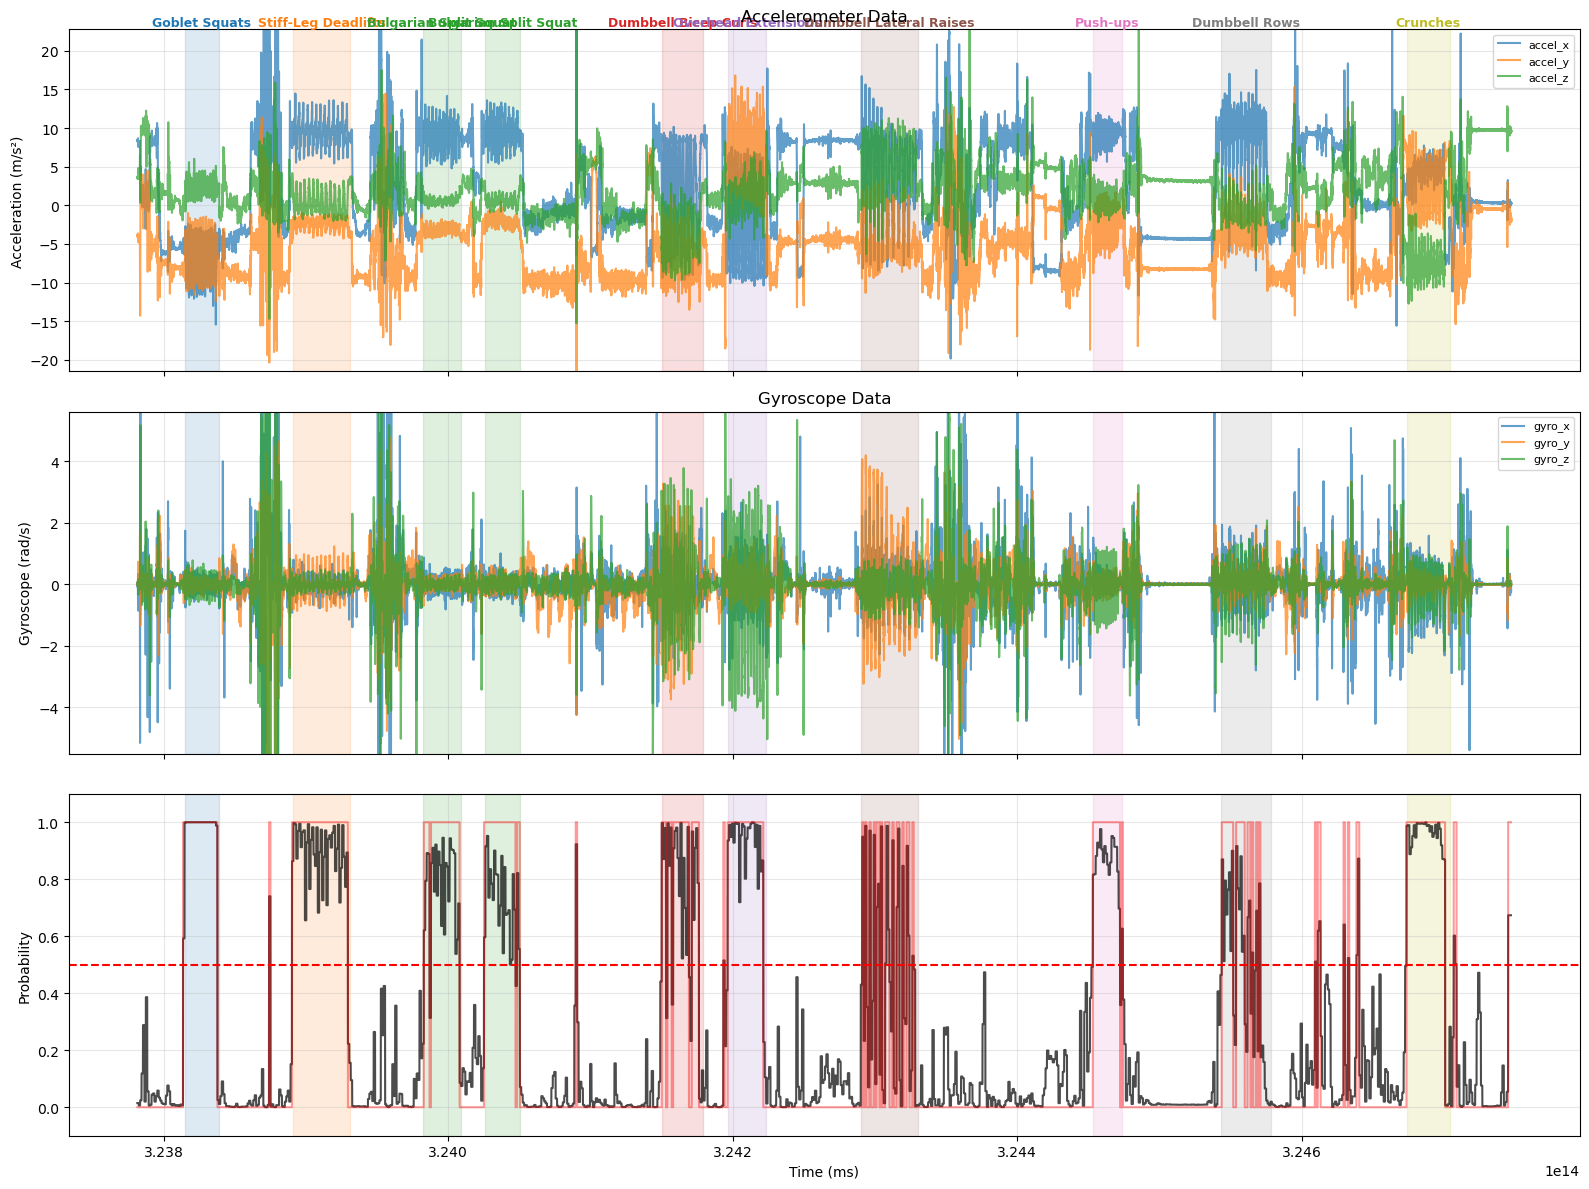

In [ ]:
plot_recording_with_predictions(combined_with_predictions)

# smooth out predictions binary

In [ ]:
df = combined_with_predictions

In [ ]:
df.rolling

<bound method NDFrame.rolling of              timestamp   accel_x   accel_y   accel_z    gyro_x    gyro_y  \
0      323781566185600  8.437167 -3.869030  3.629610  0.062308 -0.024435   
1      323781586208600  8.449138 -3.768473  3.694253  0.000000 -0.009774   
2      323781606246946  8.494628 -3.766079  3.586514 -0.050091  0.018326   
3      323781626286253  8.408437 -3.801992  3.653552 -0.057421  0.039095   
4      323781646331330  8.362946 -3.761291  3.581726 -0.068417  0.047647   
...                ...       ...       ...       ...       ...       ...   
48221  324747276810880  0.213084 -1.692701  9.600749 -0.023213 -0.014661   
48222  324747296836995  0.253785 -1.862689  9.567230 -0.031765 -0.014661   
48223  324747316858649  0.198719 -2.018312  9.603143  0.008552 -0.014661   
48224  324747336884187  0.351948 -2.087744  9.682152  0.063530 -0.032987   
48225  324747356912225  0.239420 -1.668759  9.603143  0.078191 -0.030543   

         gyro_z event  prediction_float  prediction_bi

In [ ]:
df = combined_with_predictions
for idx, row in df.iterrows():
    if idx < 3:
        continue

    previous3 = df.iloc[idx-3:idx-1]["prediction_binary"]

    print(previous3.values)

    if idx > 4:
        break

[0. 0.]
[0. 0.]
[0. 0.]
